In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


Utils

In [ ]:

import torch
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split
import numpy as np

def flexible_prop(inverse):

    """ Wrapper to help with propagating relevance """

    def prop_wrapper(layer, relevance, **kwargs) :
        if isinstance(relevance, LayerRelevance) :
            msg = relevance.scatter(-1)
            msg = inverse(layer, msg)
            relevance.gather([(-1, msg)])
        else :
            relevance = inverse(layer, relevance)

        return relevance

    return prop_wrapper

def pprint(*args):
    out = [str(argument) + "\n" for argument in args]
    print(*out, "\n")
class Flatten(torch.nn.Module):
    def __init__(self):
        super(Flatten, self).__init__()

    def forward(self, in_tensor):
        return in_tensor.view((in_tensor.size()[0], -1))


def scale_mask(mask, shape):

    if shape == mask.shape:
        print("No rescaling necessary.")
        return mask

    nmm_map = np.zeros(shape)
    for lbl_idx in np.unique(mask):
        nmm_map_lbl = mask.copy()
        nmm_map_lbl[lbl_idx != nmm_map_lbl] = 0
        nmm_map_lbl[lbl_idx == nmm_map_lbl] = 1
        zoomed_lbl = zoom(nmm_map_lbl, 1.5, order=3)
        zoomed_lbl[zoomed_lbl != 1] = 0
        remain_diff = np.array(nmm_map.shape) - np.array(zoomed_lbl.shape)
        pad_left = np.array(np.ceil(remain_diff / 2), dtype=int)
        pad_right = np.array(np.floor(remain_diff / 2), dtype=int)
        nmm_map[pad_left[0]:-pad_right[0], pad_left[1]:-pad_right[1], pad_left[2]:-pad_right[2]] += zoomed_lbl * lbl_idx

    return nmm_map

class LayerRelevance(torch.Tensor) :

    """
    LayerRelevance(relevance=None, contrastive=False, print_decimals=5)

    Custom tensor subclass for modeling relevance at any layer

    Attributes
    ----------

    relevance : torch.Tensor
        Input relevance

    contrastive : bool
        Implement relevance propagation as contrastive

    print_decimals : int
        Amount of decimals to use in printing

    Methods
    -------

    scatter(which=None, destroy=True)
        Scatters relevance to messages.

    pop_cache(rev_idx)
        Pop cached relevance storage.

    gather(relevance)
        Gather relevance messages.

    snapshot(cached=False)
        Save a copy of relevance as numpy array

    """
    HANDLED_FUNCTIONS = { }

    @staticmethod
    def __new__(cls, relevance=None, contrastive=False, print_decimals=3, *args, **kwargs) :

        return super().__new__(cls, [], *args, **kwargs)


    def __init__(self, relevance=None, contrastive=False, print_decimals=5):

        self.contrastive = contrastive
        self.print_decimals = print_decimals


        # Dual relevance stored as duplicate batch upon initialization
        if isinstance(relevance, list) :

            rel_distribution = relevance

        elif isinstance(relevance, torch.Tensor) :

            if contrastive :
                rel_distribution = [(-1, torch.cat([relevance[0], relevance[1]], dim=0))]
            else :
                rel_distribution = [(-1, relevance)]

        elif isinstance(relevance, tuple) :

            if contrastive :
                rel_distribution = [(relevance[0], torch.cat([relevance[1], relevance[2]], dim=0))]
            else :
                rel_distribution = [relevance]

        elif relevance is None :
            rel_distribution = None

        else :
            raise Exception('Could not convert type {} to input relevance'.
                  format(type(relevance)))

        self.cache = {}
        self.tensor = torch.tensor([])
        if rel_distribution is not None :
            self.gather(rel_distribution)

    def __str__(self) :

        layer_rel = 0.0
        if self.contrastive :
            if self.tensor.size(0) != 0 :
                layer_rel_primal = self.tensor[0].sum().item()
                layer_rel_dual = self.tensor[1].sum().item()
                cached_rel = { key : [v[0].sum().item(), v[1].sum().item()] \
                               for key, v in self.cache.items() }
                total = layer_rel_primal + layer_rel_dual +\
                        sum([sum(v) for v in cached_rel.values()])
                layer_rel_primal /= total
                layer_rel_dual /= total
                cached_rel =  { key : [v[0]/total, v[1]/total] \
                                for key, v in cached_rel.items() }

                layer_rel_primal = round(layer_rel_primal, self.print_decimals)
                layer_rel_dual = round(layer_rel_dual, self.print_decimals)
                layer_rel = 'P:{}/D:{}'.format(layer_rel_primal, layer_rel_dual)
            else :
                cached_rel = { key : [v[0].sum().item(), v[1].sum().item()] \
                               for key, v in self.cache.items() }
                total = sum([ sum(v) for v in cached_rel.values()])
                cached_rel = { key : [ round(v[0] / total, self.print_decimals),
                                       round(v[1] / total, self.print_decimals)] \
                               for key, v in cached_rel.items() }
            cached_rel= ' '.join([ '({}, '.format(key) +
                                   'P:{}'.format(round(v[0], self.print_decimals)) +
                                   '/D:{})'.format(round(v[1], self.print_decimals))
                                   for key,v in cached_rel.items() ])

        else :
            layer_rel = self.tensor.sum().item()
            cached_rel = { k : v.sum().item() for k,v in self.cache.items() }

            total = layer_rel + sum(cached_rel.values())
            layer_rel = round(layer_rel / total, self.print_decimals)
            cached_rel = { k : round(v / total, self.print_decimals) \
                           for k,v in cached_rel.items()}
            cached_rel = ' '.join(['({}, {})'.format(k,v) for k,v in cached_rel.items()])

        return 'LayerRelevance({}, cache={}, contrastive={})'.\
               format(layer_rel, cached_rel, self.contrastive)


    def scatter(self, which=None, destroy=True):

        """
        Scatters relevance to messages.

        Arguments
        ---------

        which : int
            Layer from which to scatter relevance

        destroy : bool
            Deletes all relevance from the structure that has been scattered

        Returns
        -------

        torch.Tensor
            Relevance tensor currently scattered

        or when which is None

        list
            List of relevance message tuplse of the form (layer, relevance message)

        """

        if which is None :
            relevance = [(-1, self.tensor)] +\
                        [(to, msg) for to, msg in self.cache.items()]

            if destroy :
                del self.tensor, self.cache
                self.tensor = torch.tensor([])
                self.cache = {}
        else :
            if which == -1 :
                relevance = self.tensor
                if destroy :
                    del self.tensor
                    self.tensor = torch.tensor([])
            else :
                relevance = self.cache[which]
                if destroy :
                    del self.cache[which]

        return relevance

    def pop_cache(self, rev_idx) :

        """
        Pop cached relevance storage

        Arguments
        ---------

        rev_idx : int
            Index to the layer of interest to pop cache for, numbered from
            top layer to back layer.

        Returns
        -------

            None

        """

        try:
            if isinstance(self.tensor, list) :
                return
            if self.tensor.nelement() != 0 :
                self.tensor += self.cache[rev_idx]
            else :
                self.tensor = self.cache[rev_idx]
            del self.cache[rev_idx]
        except KeyError :
            pass

    def gather(self, relevance) :

        """
        Gather relevance messages.

        Arguments
        ---------

            relevance : list
                List of relevance messages of the form (layer, relevance message)

        Returns
        -------

            None
        """

        for to, msg in relevance :
                if to != -1 :
                    self.cache[to] = msg
                else :
                    if self.tensor.nelement() == 0 :
                        self.tensor = msg
                    else :
                        self.tensor += msg

    def snapshot(self, cached=False) :

        """
        Save a copy of relevance as numpy array. Using cached=True includes both the
        current layer relevance as well as the cached relevance.

        Arguments
        ---------

            None

        Returns
        -------

            numpy.array
                Relevance at current layer

            dict
                Relevance assigned to each layer

        """

        if not cached :
            return self.tensor.cpu().numpy()
        return dict([(-1, self.tensor.cpu().numpy())] +\
                    [(k, v.cpu().numpy()) for k, v in self.cache.items()])

    def __torch_function__(self, func, types, args=(), kwargs=None):

        if kwargs is None :
            kwargs = {}
        if func not in LayerRelevance.HANDLED_FUNCTIONS or\
                not all(issubclass(t, (torch.Tensor, LayerRelevance)) for t in types):

            args = [a.tensor if hasattr(a, 'tensor') else a for a in args]
            res = func(*args, **kwargs)

            if type(res) is torch.Tensor :
                self.tensor = res
                return self.scatter()
            else :
                return res

        return LayerRelevance.HANDLED_FUNCTIONS[func](*args, **kwargs)

Common

In [ ]:
import torch

from torch.nn.functional import max_unpool2d, max_pool2d
#from .utils import LayerRelevance

def prop_SPPF(*args):

    inverter, mod, relevance = args

    relevance = inverter(mod.cv2, relevance)
    msg = relevance.scatter(which=-1)
    ch = msg.size(1) // 4

    r3 = msg[:, 3*ch:4*ch, ...]
    r2 = msg[:, 2*ch:3*ch, ...] + r3
    r1 = msg[:, ch:2*ch, ...] + r2
    rx = msg[:, :ch, ...] + r1

    msg = inverter(mod.cv1, rx)
    relevance.gather([(-1, msg)])

    return relevance

def SPPF_fwd_hook(m, in_tensor: torch.Tensor, out_tensor: torch.Tensor):

    x = m.cv1(in_tensor[0])
    y1, idx1 = max_pool2d(x, kernel_size = m.m.kernel_size,
                             stride=m.m.stride,
                             padding=m.m.padding,
                             dilation=m.m.dilation,
                             return_indices=True,
                             ceil_mode=m.m.ceil_mode)
    y2, idx2 = max_pool2d(y1, kernel_size = m.m.kernel_size,
                              stride=m.m.stride,
                              padding=m.m.padding,
                              dilation=m.m.dilation,
                              return_indices=True,
                              ceil_mode=m.m.ceil_mode)
    y3, idx3 = max_pool2d(y2, kernel_size = m.m.kernel_size,
                              stride=m.m.stride,
                              padding=m.m.padding,
                              dilation=m.m.dilation,
                              return_indices=True,
                              ceil_mode=m.m.ceil_mode)
    setattr(m, "indices", [idx1, idx2, idx3])

def Concat_fwd_hook(m, in_tensors: torch.Tensor, out_tensor: torch.Tensor):

    shapes = [in_tensor.shape[m.d] for in_tensor in in_tensors[0]]

    setattr(m, "in_shapes", shapes)
    setattr(m, "out_shape", out_tensor.shape)

def prop_Concat(*args):

    _, mod, relevance = args

    slices = relevance.scatter(-1).split(mod.in_shapes, dim=mod.d)
    relevance.gather([(to, msg) for to, msg in zip(mod.f, slices)])

    return relevance

def prop_Detect(*args):

    inverter, mod, relevance = args
    relevance_out = []

    _, scattered = relevance.scatter()[0]
    prop_to = [21, 18, 15][::-1]
    for i, rel in enumerate(scattered):
        relevance_out.append((prop_to[i], inverter(mod.cv3[i], rel)))
        inverter(mod.cv3[i], rel)

    relevance.gather(relevance_out)
    return relevance


def prop_Conv(*args):

    inverter, mod, relevance = args
    return inverter(mod.conv, relevance)


def prop_C3(*args):

    inverter, mod, relevance = args
    msg = relevance.scatter(which=-1)

    c_ = msg.size(1)

    msg_cv1 = msg[:, : (c_ // 2), ...]
    msg_cv2 = msg[:, (c_ // 2) :, ...]

    for m1 in mod.m:
        msg_cv1 = inverter(m1, msg_cv1)

    msg = inverter(mod.cv1, msg_cv1) + inverter(mod.cv2, msg_cv2)

    relevance.gather([(-1, msg)])

    return relevance

def prop_Bottleneck(*args):

    inverter, mod, relevance_in = args

    ar = mod.cv2.conv.out_tensor.abs()
    ax = mod.cv1.conv.in_tensor.abs()

    relevance = relevance_in
    relevance = inverter(mod.cv1, relevance)
    relevance = inverter(mod.cv2, relevance)

    return relevance


def prop_C2f(*args):
    # Extract relevant tensors from the module

    inverter, mod, relevance = args
    msg = relevance.scatter(which=-1)
    msg_cv2 = inverter(mod.cv2, msg)
    msg_m = list(msg_cv2.chunk(msg_cv2.size(1) // mod.c, 1))

    # Relevance propagation through the bottleneck blocks (m)
    for i, m_block in enumerate(mod.m[::-1]):
        msg_m[-(i+2)] += inverter(m_block, msg_m[-(i+1)])
    msg_cv1 = torch.cat(msg_m[:2], axis=1)
    msg = inverter(mod.cv1, msg_cv1)
    relevance.gather([(-1, msg)])
    return relevance


def prop_DFL(*args) :

    _, _, a = mod.in_shape
    inverter, mod, relevance = args
    relevance = inverter(relevance.unsqueeze(0), mod.conv.weight.data).transpose(2, 1)
    relevance = torch.cat([ relevance[0,:,:,ai].flatten().unsqueeze(-1) for ai in range(a) ], axis=-1).unsqueeze(0)

    return relevance

Initializers

In [ ]:
import torch
#from .utils import LayerRelevance

class YOLOv8RelevanceInitializer(object):

    """
    Assign initial relevance for YOLOv5 model explanation

    Attributes
    ----------

    cls : int

        Index to the class of interest.

    conf_thres : float

        Threshold set for object detection confidence. All output tiles
        with a confidence score lower than this will be truncated to zero

    max_class_only : bool

        Zero all output activations from classes that are not the max.

    contrastive : bool

        Whether to implement relevance as contrastive or not.

    Methods
    -------

    set_class(cls=None) :
        Set class of interest

    set_prediction(prediction=None) :
        Set prediction

    __call__(prediction : list) :
        Set initial relevance based on prediction made by YOLOv5 model

    """

    def __init__(self, cls : int = None, conf : bool = False,
                 max_class_only : bool = False, contrastive : bool = False):

        if contrastive :
            assert cls is not None, "Contrastive implementation of lrp requires target class specification"

        self.cls = cls
        self.conf = conf
        self.max_class_only = max_class_only
        self.contrastive = contrastive

        # prop_to has to do with the YOLOv5 head architecture, more specifically it defines
        # the module numbers that relevance originates from. If this chages the list bellow
        # must be manually changed.
        self.prop_to = [15, 18, 21]

    def __call__(self, cls_preds : list):

        initial_relevance = []
        norm = 0.0
        for j, cls_pred in enumerate(cls_preds):

            dimensions = cls_pred.size()

            # Keep only max class outputs (the rest may be discarded as noise)
            max_class, i = cls_pred.max(dim=1, keepdim=True)
            if self.max_class_only :
                cls_pred = torch.zeros_like(cls_pred).scatter(1, i, max_class)

            # Filter out only class of interest
            if self.cls is not None :

                # Construct dual relevance
                if self.contrastive :
                    dual = cls_pred.clone()
                    dual[:, self.cls] = 0.0

                cls_pred[:, :self.cls] = 0.0
                cls_pred[:, self.cls+1:] = 0.0

            # Reshape after we're done with processing
            if self.contrastive :
                cls_pred = torch.cat([cls_pred, dual], dim=0)

            norm += cls_pred.sum()
            initial_relevance += [ cls_pred ]

        return LayerRelevance(relevance=[ (-1, initial_relevance) ], contrastive=self.contrastive)

Inverter_util

In [ ]:
from numpy import iterable
import torch
import torch.nn.functional as F



def winner_takes_all(relevance_in : torch.Tensor, in_shape : iterable, indices : torch.Tensor ) -> torch.Tensor :

    """
    Implements winner takes-all scheme for re-distibution of relevance
    for a max pooling layer

    Arguments
    ---------

    relevance_in : torch.Tensor
        Incoming relevance from upper layers.

    in_shape : list or tuple
        Shape of module input.

    indices : torch.Tensor
        Indexes of selected (max) features.

    Returns
    -------

    relevance_out : torch.Tensor
        Relevance redistributed to lower layer.

    """
    # (REAL SLOW, MAKE THIS FASTER !)

    B, C, H, W = relevance_in.size()
    N = H * W
    relevance_out = []

    for rin in relevance_in :
        rout = torch.zeros(in_shape).flatten()
        relevance_flat = rin.flatten()

        for i, idx in enumerate(indices.flatten()):
            rout[idx + (i // N) * N] += relevance_flat[i]

        relevance_out.append(rout.view(in_shape))

    return torch.cat(relevance_out, dim=0)

def conv_nd_fwd_hook(m, in_tensor, out_tensor):

    """ Default n-dimensional convolution forward hook """

    setattr(m, "in_tensor", in_tensor[0])
    setattr(m, "out_tensor", out_tensor)

def max_pool_nd_fwd_hook(m, in_tensor, out_tensor):

    """ Default n-dimensional max pool forward hook """

    cache = m.return_indices
    _, indices = F.max_pool2d(in_tensor[0], kernel_size=m.kernel_size, stride=m.stride, padding=m.padding,
                              dilation=m.dilation, return_indices=True, ceil_mode=m.ceil_mode)
    setattr(m, "indices", indices)
    setattr(m, 'out_shape', out_tensor.size())
    setattr(m, 'in_shape', in_tensor[0].size())

def upsample_fwd_hook(m, in_tensor, out_tensor):

    """ Default up-sampling forward hook """

    setattr(m, 'in_dim', len(in_tensor[0].shape))
    setattr(m, 'out_shape', out_tensor.shape)

def linear_fwd_hook(m, in_tensor, out_tensor):

    """ Default Linear layer forward hook  """

    setattr(m, "in_tensor", in_tensor[0])
    setattr(m, "out_shape", list(out_tensor.size()))

def silent_pass(m, in_tensor, out_tensor):

    """ Silent forward hook that saves nothing """

    pass

def LogSoftmax_inverse(relevance : torch.Tensor, warn : bool = True) -> torch.Tensor :

    """
    Inversion of LogSoftmax layer

    Arguments
    ---------

    relevance : torch.Tensor
        Input relavance

    warn : bool
        Display warning message when applied

    Returns
    -------

    torch.Tensor
        Output relevance
    """

    if relevance.sum() < 0:
        relevance[relevance == 0] = -1e6
        relevance = relevance.exp()
        if warn :
            pprint("WARNING: LogSoftmax layer was "
                   "turned into probabilities.")

    return relevance

@flexible_prop
def max_pool_nd_inverse(layer, relevance_in : torch.Tensor, indices : torch.Tensor = None,
                        max : bool = False) -> torch.Tensor :

    """
    Inversion of LogSoftmax layer

    Arguments
    ---------

    relevance : torch.Tensor
        Input relavance

    indices : torch.Tensor
        Maximum feature indexes obtained when max pooling

    max : bool
        Implement winner takes all scheme in relevance re-distribution

    Returns
    -------

    torch.Tensor
        Output relevance
    """

    if indices is None :
        indices = layer.indices

    out_shape = layer.out_shape
    bs = relevance_in.size(0)
    relevance_in = torch.cat([r.view(out_shape) for r in relevance_in ], dim=0)

    indices = torch.cat([indices] * bs, dim=0)

    return ( winner_takes_all(relevance_in, layer.in_shape, layer.indices)
             if max else relevance_in )


@flexible_prop
def upsample_inverse(layer, relevance : torch.Tensor) -> torch.Tensor :

    """
    Inversion of upsample layer

    Arguments
    ---------

    relevance : torch.Tensor
        Input relavance

    Returns
    -------

    torch.Tensor
        Output relevance

    ATTENTION : Currently only 'nearest' upsampling method is invertable
    """

    invert_upsample = {
        1 : F.avg_pool1d,
        2 : F.avg_pool2d,
        3 : F.avg_pool3d
    } [layer.in_dim - 2]

    if layer.mode != 'nearest' :
        raise NotImplementedError("Upsample layer must be in 'nearest' mode ")
    relevance_in = torch.cat([r.view(layer.out_shape) for r in relevance], dim=0)

    if isinstance(layer.scale_factor, float):
        ks = int(layer.scale_factor)
    elif isinstance(layer.scale_factor, tuple):
        ks = tuple([ int(s) for s in layer.scale_factor ])

    inverted = invert_upsample(relevance_in, kernel_size=ks, stride=ks)
    inverted *= ks**2 # Normalizing constant

    return inverted

Inverter

In [ ]:
# trunk-ignore(black-py)
import torch
from torch.nn import Conv1d, Conv2d, Conv3d, MaxPool1d, MaxPool2d, MaxPool3d, Linear, Upsample


FWD_HOOK = { torch.nn.MaxPool1d : max_pool_nd_fwd_hook,
             torch.nn.MaxPool2d : max_pool_nd_fwd_hook,
             torch.nn.MaxPool3d : max_pool_nd_fwd_hook,
             torch.nn.Conv1d : conv_nd_fwd_hook,
             torch.nn.Conv2d : conv_nd_fwd_hook,
             torch.nn.Conv3d : conv_nd_fwd_hook,
             torch.nn.Linear : linear_fwd_hook,
             torch.nn.Upsample : upsample_fwd_hook,
             torch.nn.BatchNorm1d : silent_pass,
             torch.nn.BatchNorm2d : conv_nd_fwd_hook,
             torch.nn.BatchNorm3d : silent_pass,
             torch.nn.ReLU : silent_pass,
             torch.nn.modules.activation.ReLU : silent_pass,
             torch.nn.ELU : silent_pass,
             Flatten : silent_pass,
             torch.nn.Dropout : silent_pass,
             torch.nn.Dropout2d : silent_pass,
             torch.nn.Dropout3d : silent_pass,
             torch.nn.Softmax : silent_pass,
             torch.nn.LogSoftmax : silent_pass,
             torch.nn.Sigmoid : silent_pass,
             torch.nn.SiLU :  silent_pass }

# Rule-independant inversion functions
IDENTITY_MAPPINGS = ( torch.nn.BatchNorm1d,
                      torch.nn.BatchNorm2d,
                      torch.nn.BatchNorm3d,
                      torch.nn.ReLU,
                      torch.nn.modules.activation.ReLU,
                      torch.nn.ELU,
                      Flatten,
                      torch.nn.Dropout,
                      torch.nn.Dropout2d,
                      torch.nn.Dropout3d,
                      torch.nn.Softmax,
                      torch.nn.LogSoftmax,
                      torch.nn.Sigmoid,
                      torch.nn.SiLU )

def module_tracker(fwd_hook_func):

    """
    Wrapper for tracking the layers throughout the forward pass.

    Arguments
    ---------

        fwd_hook_func : function
            Forward hook function to be wrapped.

    Returns
    -------

        function :
            Wrapped hook function

    """

    def hook_wrapper(layer, *args):
        return fwd_hook_func(layer, *args)

    return hook_wrapper

class Inverter(torch.nn.Module):

    """
    Class for computing the relevance propagation and supplying the necessary forward hooks for all layers.

    Attributes
    ----------

    linear_rule : LinearRule
        Propagation rule to use for linear layers

    conv_rule : ConvRule
        Propagation rule for convolutional layers

    pass_not_implemented : bool
        Silent pass layers that have no registered forward hooks

    device : torch.device
        Device to put relevance data

    Methods
    -------

        Propagates incoming relevance for the specified layer, applying any
        necessary inversion functions along the way.

    """

    # Implemented rules for relevance propagation.
    def __init__(self, linear_rule=None, conv_rule=None, pass_not_implemented=False,
                 device=torch.device('cpu'),):

        self.device = device
        self.warned_log_softmax = False
        self.linear_rule = linear_rule
        self.conv_rule = conv_rule
        self.fwd_hooks = FWD_HOOK
        self.inv_funcs= {}
        self.pass_not_implemented = pass_not_implemented
        self.module_list = []

    def register_fwd_hook(self, module, fwd_hook):

        """
        Register forward hook function to module.
        """

        if module in self.fwd_hooks.keys():
            print('Warning: Replacing previous fwd hook registered for {}'.
                  format(module))

        self.fwd_hooks[module] = fwd_hook

    def register_inv_func(self, module, inv_func):

        """
        Register inverse function to module.
        """

        if module in self.inv_funcs.keys():
            print('Warning: Replacing previous inverse registered for {}'.
                  format(module))

        self.inv_funcs[module] =  inv_func

    def get_layer_fwd_hook(self, layer) :

        """
        Interface for getting any layer's forward hook
        """

        try :
            return self.fwd_hooks[type(layer)]
        except :
            if self.pass_not_implemented :
                return silent_pass

            raise \
            NotImplementedError('Forward hook for layer type \"{}\" not implemented'.
                                format(type(layer)))

    def invert(self, layer : torch.nn.Module, relevance : torch.Tensor, **kwargs) -> torch.Tensor :

        """
        This method computes the backward pass for the incoming relevance
        for the specified layer.

        Arguments
        ---------

            layer : torch.nn.Module
                Layer to propagate relevance through. Can be Conv1d, Conv2d or
                any combination thereof in a higher level module.

            relevance : torch.Tensor
                Incoming relevance from higher up in the network.

        Returns
        ------

            torch.Tensor :
                Redistributed relevance going to the lower layers in the network.

        """

        if isinstance(layer, (Conv1d, Conv2d, Conv3d)):
            if self.conv_rule is None :
                raise Exception('Model contains conv layers but the conv rule was not set !')
            return self.conv_rule(layer, relevance, **kwargs)
        elif isinstance(layer, (MaxPool1d, MaxPool2d, MaxPool3d)):
            return max_pool_nd_inverse(layer, relevance)
        elif isinstance(layer, Linear) :
            if self.linear_rule is None :
                raise Exception('Model contains linear layers but the linear rule was not set !')
            return self.linear_rule(layer, relevance.tensor, **kwargs)
        elif isinstance(layer, Upsample):
            return upsample_inverse(layer, relevance)
        elif isinstance(layer, torch.nn.modules.container.Sequential):
            for l in layer[::-1] :
                relevance = self.invert(l, relevance)
            return relevance
        elif type(layer) in IDENTITY_MAPPINGS :
            return relevance
        elif hasattr(layer, 'propagate'):
            return layer.propagate(self, relevance)
        else :
            try :
                return self.inv_funcs[type(layer)](self, layer, relevance, **kwargs)
            except KeyError :
                raise NotImplementedError(f'Relevance propagation not implemented for layer type {type(layer)}')

    def __call__(self, layer : torch.nn.Module, relevance : torch.Tensor, **kwargs) -> torch.Tensor :

        """ Wrapper for invert method """
        return self.invert(layer, relevance, **kwargs)

inverter_util

Rules

In [ ]:
# trunk-ignore(isort)
import torch
import numpy as np
import torch.nn.functional as F
from torch.nn import Conv1d, Conv2d, Conv3d
#from .utils import LayerRelevance

class LinearRule(object):

    """
    WARNING: This utility has not been tested and may contain significant errors

    LinearRule(power : int = 1, eps : float = 1e-06, positive : bool = True,
               contrastive : bool =True,)

    Apply layerwise relevance propagation rule to linear layer. Implemented using
    the procedure described here :

    http://iphome.hhi.de/samek/pdf/MonXAI19.pdf

    Attributes
    ----------

    contrastive : bool
        Compute dual relevance for contrastive

    power : int / float
        Exponent to apply to input / weights

    eps : float
        Small number added to denominator to avoid divide by zero

    positive : bool
        Truncate negative activations of prev layer to zero


    Methods
    -------

    propagate(module : torch.nn.Module, relevance : torch.Tensor) -> torch.Tensor
        Propagates incoming relevance through module and redistributes
        it to lower layers.

    """

    def __init__(self, power : int = 1, eps : float = 1e-06, positive : bool = True,
                 contrastive : bool =True,):

        self.power = power
        self.eps = eps
        self.positive = positive
        self.contrastive = contrastive

    def __call__(self, module, relevance,):

        """ Wrapper for propagate, makes rule object callable """

        return self.propagate(module, relevance)

    def propagate(self, module : torch.nn.Module, relevance : torch.Tensor,) -> torch.Tensor :

        """

        Propagate incoming relevance through module and redistribute it to lower layers.

        Arguments
        ---------

        module : torch.nn.Module (Linear)
            Module through which relevance is propagated.

        relevance : torch.Tensor
            LayerRelevance tensor or simple tensor containing upper layer relevance.

        Returns
        -------

        torch.Tensor
            Re-distributed relevance. If input is tensor output will also be tensor, and if
            it is LayerRelevance output will also be LayerRelevance tensor.

        ATTENTION : Each time LayerRelevance is "propagated" through a module it essentialy
        "morphs" into the output relevance. This is to say that any previous relevance info
        is not saved and is discarded. If for the sake of visualizing the relevance distribu-
        tion as it backpropagates through the network you need to keep a cache of each layer
        relevance you can do so by using the cache() method.

        """

        # Implementation-wise this method is just a wrapper for the private
        # propagation utillity that ensures functionallity for both LayerRelevance.
        # objects and tensors.
        if isinstance(relevance, LayerRelevance):
            msg = relevance.scatter(-1)
            msg = self.__propagate(module, msg)
            relevance.gather([(-1, msg)])
        else:
            relevance = self.__propagate(module, relevance)

        return relevance

    def __get_fwd_step(self,):

        """ Dimension non-specific forward function  """

        def linear_wrapper(in_tensor, w, **kwargs):
            if self.contrastive:
                x = torch.cat([in_tensor] * 2, dim=0)
            else:
                x = in_tensor
            return F.linear(x, w, **kwargs)

        return linear_wrapper

    def __get_bwd_step(self,):

        """ Dimension non-specific inverse function  """

        def linear_wrapper(relevance_in, w, **kwargs):
            return F.linear(relevance_in, w.t, **kwargs)

        return linear_wrapper

    def __propagate(self, module, relevance_in,):

        linear_fwd = self.__get_fwd_step()
        linear_bwd = self.__get_bwd_step()

        # Pre-process : Apply power to weights/input
        x = module.in_tensor
        x = x.pow(self.power)
        w = module.weight.pow(self.power)

        # Compute forward activation with modified weights (step 1)
        z = linear_fwd(x, w, bias=None)
        z = z + torch.sign(z) * self.eps
        relevance_in[z == 0] = 0
        z[z == 0] = 1

        # Divide incoming relevance by activation (step 2)
        s = relevance_in / z

        # Compute gradient of s in terms of its input, which the equivalent of applying
        # the de-convolution operation (see PyTorch doc) (step 3)
        c = linear_bwd(s, w, bias=None)

        # Multiply by input (step 4)
        relevance_out = c * x

        return relevance_out
class ConvRule(object):

    """

    ConvRule(power : int = 1, positive : bool = True, eps : float = 1e-6,
             contrastive : bool = True,)

    Apply layerwise relevance propagation rule to convolutional layers.
    Implemented efficiently using procedure described here :

    http://iphome.hhi.de/samek/pdf/MonXAI19.pdf

    Attributes
    ----------

    power : int / float
        Exponent to apply to input / weights

    positive : bool
        Truncate negative activations of prev layer to zero

    eps : float
        Small number added to denominator to avoid divide by zero

    contrastive : bool
        Compute dual relevance for contrastive

    Methods
    -------

    propagate(module : torch.nn.Module, relevance : torch.Tensor) -> torch.Tensor
        Propagates incoming relevance through module and redistributes
        it to lower layers.

    """

    def __init__(self, power : int = 1, eps : float = 1e-6, positive : bool = True,
                 contrastive : bool = True,) :

        self.power = power
        self.eps = eps
        self.positive = positive
        self.contrastive = contrastive

    def __call__(self, module, relevance,) ->  torch.Tensor :

        """ Wrapper for propagate, makes rule object callable """

        return self.propagate(module, relevance)

    def propagate(self, module : torch.nn.Module, relevance : torch.Tensor,) -> torch.Tensor :

        """

        Propagate incoming relevance through module and redistribute it to lower layers.

        Arguments
        ---------

        module : torch.nn.Module (Conv1d, Conv2d or Conv3d)
            Conv module through which relevance is propagated.

        relevance : torch.Tensor
            LayerRelevance tensor or simple tensor containing upper layer relevance.

        Returns
        -------

        torch.Tensor
            Re-distributed relevance. If input is tensor output will also be tensor, and if
            it is LayerRelevance output will also be LayerRelevance tensor.

        ATTENTION : Each time LayerRelevance is "propagated" through a module it essentialy
        "morphs" into the output relevance. This is to say that any previous relevance info
        is not saved and is discarded. If for the sake of visualizing the relevance distribu-
        tion as it backpropagates through the network you need to keep a cache of each layer
        relevance you can do so by using the cache() method.

        """

        # Implementation-wise this method is just a wrapper for the private propagation
        # utillity that ensures functionallity for both LayerRelevance.objects and tensors.

        if isinstance(relevance, LayerRelevance):
            msg = relevance.scatter(-1)
            msg = self.__propagate(module, msg)
            relevance.gather([(-1, msg)])
        else:
            relevance = self.__propagate(module, relevance)

        return relevance

    def __get_fwd_step(self, m):

        """ Dimension non-specific forward function  """

        try:
            conv = {Conv1d: F.conv1d, Conv2d: F.conv2d, Conv3d: F.conv3d}[type(m)]
        except:
            raise Exception("Layer must be one of {}".format((Conv1d, Conv2d, Conv3d)))

        # The only function of the following wrapper is to duplicate the input
        # tensor. This is necessary for computing contrastive relevance propagation
        # efficiently.
        def conv_wrapper(in_tensor, **kwargs):
            if self.contrastive:
                x = torch.cat([in_tensor, in_tensor], dim=0)
            else:
                x = in_tensor
            return conv(x, **kwargs)

        return conv_wrapper

    def __get_bwd_step(self, m):

        """ Dimension non-specific inverse function  """

        try:
            inv_conv = {
                Conv1d: F.conv_transpose1d,
                Conv2d: F.conv_transpose2d,
                Conv3d: F.conv_transpose3d,
            }[type(m)]
        except:
            raise Exception("Layer must be one of {}".format((Conv1d, Conv2d, Conv3d)))

        def inv_conv_wrapper(relevance_in, **kwargs):
            return inv_conv(relevance_in, **kwargs)

        return inv_conv_wrapper

    def __propagate(self, module, relevance_in):

        """ Implementation of 4-step relevance propagation procedure """

        relevance_in = torch.cat([ r.view_as(module.out_tensor) for r in relevance_in ], dim=0)
        conv_fwd = self.__get_fwd_step(module)
        conv_bwd = self.__get_bwd_step(module)

        with torch.no_grad():

            # Pre-process : Apply power to weights/input, discard negative activations
            x = torch.cat( [module.in_tensor.clone()] * relevance_in.size(0), dim=0)
            w = module.weight.clone()
            if self.positive :
                x = x.clamp(min=0)
                w = w.clamp(min=0)
            x = x.pow(self.power)
            w = w.pow(self.power)

            # Compute forward activation with modified weights (step 1)

            z = conv_fwd(x, weight=w, bias=None, stride=module.stride,
                         padding=module.padding, groups=module.groups,) #
            z = z + torch.sign(z) * self.eps
            relevance_in[z == 0] = 0
            z[z == 0] = 1

            # Divide incoming relevance by activation (step 2)
            s = relevance_in / z

            # Compute gradient of s in terms of its input, which the equivalent of applying
            # the de-convolution operation (see PyTorch doc) (step 3)
            if module.stride != (1, 1) :

                # When stride is not equal to 1 there may be some discrepancy between
                # the input and output sizes, the following code fixes this by manually
                # calculating the new H, w dimensions and adding valid padding at backward
                # step
                _, _, H, W = relevance_in.size()
                Hnew = (H - 1) * module.stride[0] - 2*module.padding[0] +\
                        module.dilation[0]*(module.kernel_size[0]-1) +\
                        module.output_padding[0]+1
                Wnew = (W - 1) * module.stride[1] - 2*module.padding[1] +\
                        module.dilation[1]*(module.kernel_size[1]-1) +\
                        module.output_padding[1]+1
                _, _, Hin, Win = x.size()

                cp = conv_bwd(s, weight=w, bias=None, padding=module.padding,
                            output_padding=(Hin-Hnew, Win-Wnew), stride=module.stride,
                            dilation=module.dilation, groups=module.groups,)
            else:
                cp = conv_bwd(s, weight=w, bias=None, padding=module.padding,
                            stride=module.stride, groups=module.groups,)


            # Multiply by input (step 4)
            relevance_out = cp*x

            return relevance_out

Utils

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.6/779.6 kB 10.8 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-

YOLO

In [ ]:
import torch
#from .utils import pprint
#from .initializers import YOLOv8RelevanceInitializer
#from .rules import ConvRule, LinearRule
#from .inverter import Inverter
#from .common import ( prop_Concat, Concat_fwd_hook, prop_Detect,
                      #prop_C3, prop_Conv, prop_Bottleneck, prop_DFL,
                      #prop_SPPF, SPPF_fwd_hook, prop_C2f )

from ultralytics.nn.modules import block, conv, head

class YOLOv8LRP(torch.nn.Module):

    """
    Generate layerwiser relevance propagation per-pixel explanation for classification
    result of Pytorch model.

    (https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0130140).

    Attributes
    ----------

    model : torch.nn.Module
        Model to explain

    conv_rule : lrp_rules.ConvRule
        Rule for relevance propagation for convolutional layers

    linear_rule : lrp_rules.LinearRule
        Rule for relevance propagation for convolutional layers

    contrastive : bool
        Implement relevance propagation as contrastive

    device : torch.device
        Device to utilize

    Methods
    -------

    cuda(device : torch.device) :
        Transfer model structure to specified cuda device. If None, the memory
        will be assigned to the first available cuda device.

    cpu(device : torch.device) :
        Use cpu device for computation.

    evaluate(in_tensor : torch.Tensor, **kwargs) -> torch.Tensor :
        Evaluates the model on a new input. The registered forward hooks will
        save all the data that is necessary to compute the relevance per neuron
        per layer.

    ATTENTION:
        Currently, generating heatmaps for a network only works if all
        layers that have to be inverted are specified explicitly
        and registered as a module. If for example,
        the functional max_poolnd is used, the inversion will not work.
    """

    def __init__(self, model : torch.nn.Module,
                 contrastive : bool = False,  power : int = 1, positive : bool = True, eps : float = 1e-6,
                 device :  torch.device = torch.device('cpu')):

        super(YOLOv8LRP, self).__init__()
        self.model = model
        self.device = device
        self.prediction = None
        self.r_values = None
        self.only_max_score = None
        self.contrastive = contrastive
        self.device = device
        conv_rule = ConvRule(power=power,
                             positive=positive,
                             eps=eps,
                             contrastive=contrastive)
        linear_rule = LinearRule(power=power,
                                 positive=positive,
                                 eps=eps,
                                 contrastive=contrastive)
        self.linear_rule = LinearRule
        self.layerwise_relevance = []
        self.save_r_values = False


        # Initialize the 'Relevance Propagator' with the chosen rule.
        # This will be used to back-propagate the relevance values
        # through the layers.
        self.inverter = Inverter(linear_rule=linear_rule,
                                 conv_rule=conv_rule,
                                 pass_not_implemented=True,
                                 device=self.device)
        self.register_new_modules({ conv.Concat : Concat_fwd_hook,
                                    block.SPPF : SPPF_fwd_hook },
                                  { block.C3 : prop_C3,
                                    block.Conv : prop_Conv,
                                    head.Detect : prop_Detect,
                                    block.Bottleneck : prop_Bottleneck,
                                    conv.Concat : prop_Concat,
                                    block.SPPF : prop_SPPF,
                                    block.DFL : prop_DFL,
                                    block.C2f : prop_C2f })

        # Parsing the individual model layers
        self.register_hooks(self.model.model.model)
        self.register_modules(self.model.model.model)

        self.relevance_cache = {}

    def cuda(self, device : torch.device = None):

        """
        Transfer model structure to specified cuda device. If None, the memory
        will be assigned to the first available cuda device.

        Arguments
        ---------

        device : torch.device
            Device to put memory into.

        Returns
        -------

            None
        """

        self.device = torch.device("cuda", device)
        self.inverter.device = self.device
        return super(YOLOv8LRP, self).cuda(device)

    def cpu(self):

        """
        Use cpu device for computation.

        Arguments
        ---------

            None

        Returns
        -------

            None
        """
        self.device = torch.device("cpu", 0)
        self.inverter.device = self.device
        return super(YOLOv8LRP, self).cpu()

    def register_modules(self, entry_point : torch.nn.Module, no_children : bool = False) :

        if no_children :
            self.inverter.module_list.append(entry_point)
        else :
            for mod in entry_point.children():
                setattr(mod, 'reg_num', len(self.inverter.module_list))

                self.inverter.module_list.append(mod)

    def register_hooks(self, parent_module : torch.nn.Module):

        """
        Registers any necessary forward hooks that save input and output tensors
        for later computation of relevance distribution.

        Args
        ----

        parent_module : torch.nn.Module
            Model to register hooks for.

        Returns
        -------

            None

        """

        for mod in parent_module.children():


            if list(mod.children()):
                self.register_hooks(mod)

            if len(mod._forward_hooks) == 0:
                mod.register_forward_hook(self.inverter.get_layer_fwd_hook(mod))

            # Special case for ReLU layer
            if isinstance(mod, torch.nn.ReLU) or isinstance(mod, torch.nn.modules.activation.ReLU):
                mod.register_backward_hook(self.relu_hook_function)

    def register_new_modules(self, fwd_hooks : dict = {}, inv_funcs : dict = {}) :

        for mod, fwd_hook in fwd_hooks.items() :
            self.inverter.register_fwd_hook(mod, fwd_hook)

        for mod, inv_func in inv_funcs.items() :
            self.inverter.register_inv_func(mod, inv_func)

    @staticmethod
    def relu_hook_function(module, grad_in, grad_out):

        """
        If there is a negative gradient, change it to zero.
        """

        return (torch.clamp(grad_in[0], min=0.0),)

    def __call__(self, in_tensor):

        """
        The explanation wrapper returns the same prediction as the
        original model, but wraps the model call method in the evaluate
        method to save the last prediction.

        Arguments
        ---------

        in_tensor : torch.Tensor
            Model input to pass through the pytorch model.

        Returns
        -------

        torch.Tensor
            Model output
        """

        return self.evaluate(in_tensor)

    def evaluate(self, in_tensor : torch.Tensor, **kwargs) -> torch.Tensor :

        """
        Evaluates the model on a new input. The registered forward hooks will
        save all the data that is necessary to compute the relevance per neuron per layer.

        Arguments
        ---------

        in_tensor : torch.Tensor
            New input for which to predict an output.

        Returns
        -------

        torch.Tensor
            Model prediction
        """

        # Reset module list. In case the structure changes dynamically,
        # the module list is tracked for every forward passs.
        # self.inverter.reset_module_list()

        self.prediction = self.model.model(in_tensor.unsqueeze(0), **kwargs)
        return self.prediction

    def get_r_values_per_layer(self):

        """
        Get relevance snapshots per layer in the network.

        Arguments
        --------

        None

        Returns
        -------

        list
            list of relevance snapshots

        """

        if self.r_values is None:
            pprint("No relevances have been calculated yet, returning None in"
                   " get_r_values_per_layer.")
        return self.r_values

    def explain(self, frame, cls= None, conf=False, max_class_only=True, contrastive=False,
                b1=0.5, b2=0.5):

        """
        Method for generating an explanatort heatmap for the model with the LRP rule chosen at
        the initialization of the module.

        Arguments
        ---------

        frame : torch.Tensor
            Input frame for which to evaluate the LRP algorithm.

        cls : int
            Index of the class for which the relevance distribution is to be analyzed.
            If None, the 'winning' class is used for indexing.

        Returns
        -------

        LayerRelevance
            Model output and relevances of nodes in the input layer
        """

        if self.r_values is not None:
            for elt in self.r_values:
                del elt
            self.r_values = None

        if isinstance(cls, str):
            cls = list(self.model.names.values()).index(cls)

        with torch.no_grad():

            # We have to iterate through the model backwards.
            # The module list is computed for every forward pass
            # by the model inverter.
            rev_model = self.inverter.module_list[::-1]

            initializer = YOLOv8RelevanceInitializer(cls=cls, max_class_only=max_class_only,
                                                     conf=conf, contrastive=contrastive)

            self.model.model.predict(frame.unsqueeze(0))

            cls_preds = [ conv[-1].out_tensor.sigmoid() for conv in self.model.model.model[-1].cv3 ]
            relevance = initializer(cls_preds=cls_preds)

            # List to save relevance distributions per layer
            self.r_values = [relevance]
            for layer in rev_model:
                # Compute layer specific backwards-propagation of relevance values
                relevance.pop_cache(layer.reg_num)
                self.r_values.append(relevance)
                relevance = self.inverter(layer, relevance)

            if self.save_r_values :
                self.r_values.append(relevance.snapshot())

            if self.device == "cuda":
                torch.cuda.empty_cache()

            lrp_out = relevance.scatter(-1)

            if contrastive :
                lrp_p = lrp_out[[0]]
                lrp_d = lrp_out[[1]]
                top_5_percent_threshold = torch.quantile(lrp_p, 0.98)
                outlier_mask = lrp_p < top_5_percent_threshold
                lrp_p = torch.where(outlier_mask, lrp_p, torch.tensor(0.0))
                top_5_percent_threshold = torch.quantile(lrp_p, 0.98)
                outlier_mask = lrp_d < top_5_percent_threshold
                lrp_d = torch.where(outlier_mask, lrp_d, torch.tensor(0.0))

                explanation  = (b1*lrp_p - b2*lrp_d).sum(dim=1)[0]
            else :
                lrp_p = lrp_out[[0]]
                lrp_p = lrp_p.sum(dim=1)[0]
                top_5_percent_threshold = torch.quantile(lrp_p, 0.98)
                outlier_mask = lrp_p < top_5_percent_threshold
                explanation = torch.where(outlier_mask, lrp_p, torch.tensor(0.0))


            return explanation

    def forward(self, in_tensor : torch.Tensor) -> torch.Tensor :

        """
        Evaluates model on a given input tensor.

        Arguments
        ---------

        in_tensor : torch.Tensor
            Model input tensor.

        Returns
        -------

        torch.Tensor
            Model output tensor.
        """

        return self.model(in_tensor)

    def extra_repr(self):

        """
        Set the extra representation of the module

        To print customized extra information, you should re-implement
        this method in your own modules. Both single-line and multi-line
        strings are acceptable.
        """

        return self.model.extra_repr()

Own model

In [ ]:
from ultralytics import YOLO
#from lrp.yolo import YOLOv8LRP
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms

In [ ]:
image = Image.open("/content/f239c3ba-40_10.png")

desired_size = (512, 640)
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize(desired_size),
    torchvision.transforms.ToTensor(),
])

image = transform(image).float()
image.shape

torch.Size([3, 512, 640])

In [ ]:
yolo = YOLO('/content/gdrive/MyDrive/Yolo_images/Trained_model/best (1).pt')
detection = yolo(image)


WARNING ⚠️ torch.Tensor inputs should be BCHW i.e. shape(1, 3, 640, 640) divisible by stride 32. Input shape(3, 512, 640) is incompatible.
0: 512x640 1 Fully Tight Screw, 2 Loose Screws, 2368.6ms
Speed: 0.0ms preprocess, 2368.6ms inference, 7.7ms postprocess per image at shape (1, 3, 512, 640)


In [ ]:
# Instantiate a w2-rule relevance propagation object
lrp = YOLOv8LRP(yolo, power=2, eps=1e-05, device='cpu')

In [ ]:
explanation_lrp_tight = lrp.explain(image, cls='Fully Tight Screw', contrastive=False).cpu()
explanation_lrp_loose = lrp.explain(image, cls='Loose Screw', contrastive=False).cpu()
explanation_lrp_missing = lrp.explain(image, cls='Missing Screw', contrastive=False).cpu()

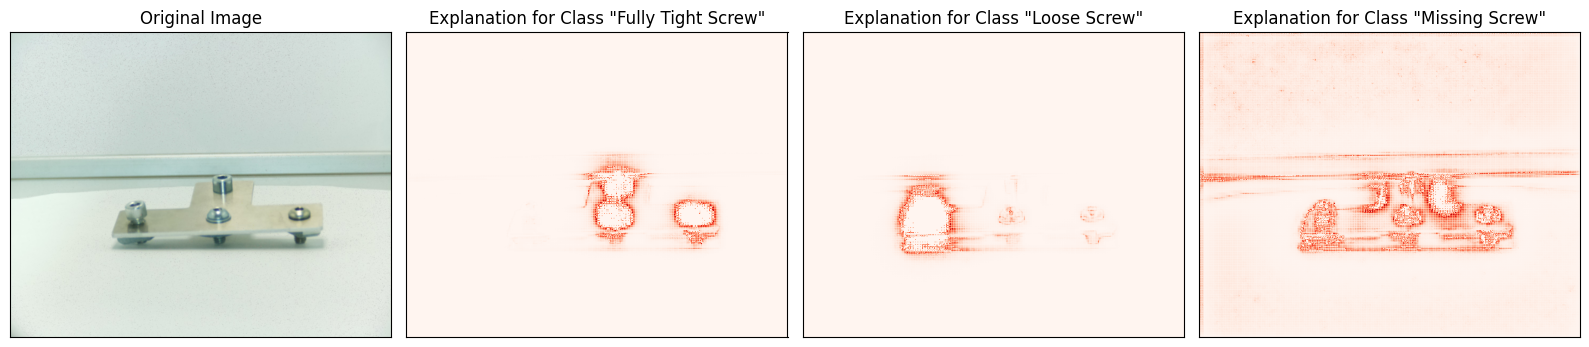

In [ ]:
# Plotting the original image
plt.figure(figsize=(16,16))
plt.subplot(1, 4, 1)
plt.imshow(torch.cat([image[c, :, :].cpu().unsqueeze(-1) for c in range(3)], axis=-1))
plt.title('Original Image')
plt.xticks([]); plt.yticks([])

# Plotting the explanation for class 'Fully tight screw crp'
plt.subplot(1, 4, 2)
plt.imshow(explanation_lrp_tight, cmap='Reds')
maxrel = np.abs(explanation_lrp_tight).max()
plt.clim(vmin=0, vmax=maxrel)
plt.title('Explanation for Class "Fully Tight Screw"')
plt.xticks([]); plt.yticks([])

# Plotting the explanation for class Loose Screw
plt.subplot(1, 4, 3)
# Assuming 'explanation_loose' is a numpy array for the explanation of class 'Loose Screw'
plt.imshow(explanation_lrp_loose, cmap='Reds')
maxrel_cat = np.abs(explanation_lrp_loose).max()
plt.clim(vmin=0, vmax=maxrel_cat)
plt.title('Explanation for Class "Loose Screw"')
plt.xticks([]); plt.yticks([])

plt.subplot(1, 4, 4)
# Assuming 'explanation_missing' is a numpy array for the explanation of class 'Missing Screw'
plt.imshow(explanation_lrp_missing, cmap='Reds')
maxrel_cat = np.abs(explanation_lrp_missing).max()
plt.clim(vmin=0, vmax=maxrel_cat)
plt.title('Explanation for Class "Missing Screw"')
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()

In [ ]:
# Generate CRP explanations for both classes
explanation_crp_tight = lrp.explain(image, cls='Fully Tight Screw', contrastive=True,).cpu()
explanation_crp_loose = lrp.explain(image, cls='Loose Screw', contrastive=True,).cpu()
explanation_crp_missing = lrp.explain(image, cls='Missing Screw', contrastive=True,).cpu()

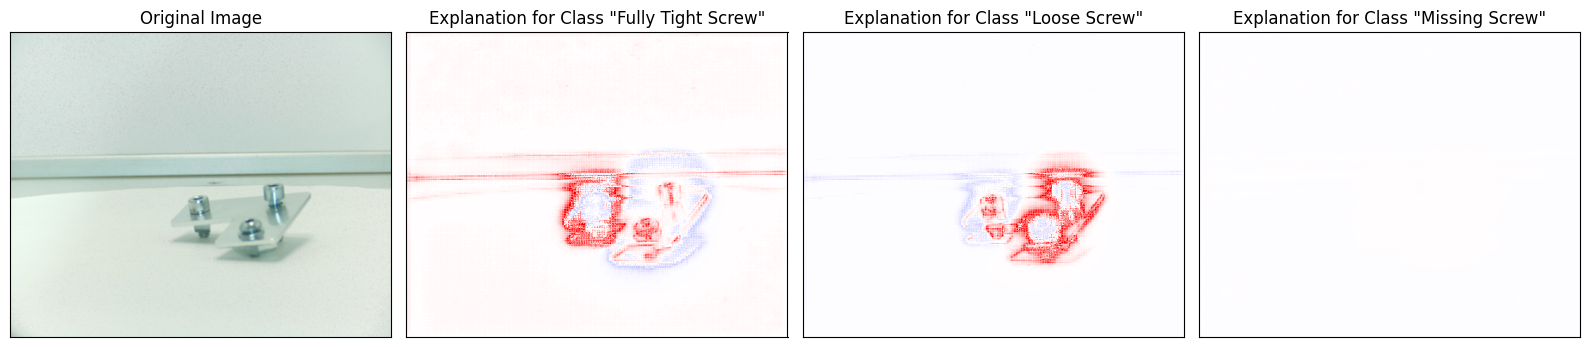

In [ ]:
# Plotting the original image
plt.figure(figsize=(16,16))
plt.subplot(1, 4, 1)
plt.imshow(torch.cat([image[c, :, :].cpu().unsqueeze(-1) for c in range(3)], axis=-1))
plt.title('Original Image')
plt.xticks([]); plt.yticks([])

# Plotting the explanation for class 'Tight Screw'
plt.subplot(1, 4, 2)
plt.imshow(explanation_crp_tight, cmap='seismic')
maxrel = np.abs(explanation_crp_tight).max()
plt.clim(vmin=-maxrel, vmax=maxrel)
plt.title('Explanation for Class "Fully Tight Screw"')
plt.xticks([]); plt.yticks([])

# Plotting the explanation for class 'Loose Screw'
plt.subplot(1, 4, 3)
# Assuming 'explanation_loose' is a numpy array for the explanation of class 'Loose Screw'
plt.imshow(explanation_crp_loose, cmap='seismic')
maxrel_cat = np.abs(explanation_crp_loose).max()
plt.clim(vmin=-maxrel_cat, vmax=maxrel_cat)
plt.title('Explanation for Class "Loose Screw"')
plt.xticks([]); plt.yticks([])

# Plotting the explanation for class 'Missing Screw'
plt.subplot(1, 4, 4)
# Assuming 'explanation_loose' is a numpy array for the explanation of class 'Loose Screw'
plt.imshow(explanation_crp_missing, cmap='seismic')
maxrel_cat = np.abs(explanation_crp_loose).max()
plt.clim(vmin=-maxrel_cat, vmax=maxrel_cat)
plt.title('Explanation for Class "Missing Screw"')
plt.xticks([]); plt.yticks([])

plt.tight_layout()
plt.show()